In [2]:
%pip install pandas numpy matplotlib

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.7 MB 4.0 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.7 MB 4.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.7 MB 4.3 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.7 MB 4.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.7 MB 4.4 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.7 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.7 MB 4.4 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 4.3 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.7 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 4.3 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
ROOT = Path("wandb_run_files")
FIG_DIR = Path("figures/overall_performance")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(ROOT.resolve())
print(FIG_DIR.resolve())

\\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_run_files
\\wsl.localhost\Ubuntu\home\lly\projects\project\figures\overall_performance


In [5]:
model_order = [
    "qwen25_3b",
    "qwen25_7b",
    "qwen35_4b",
    "qwen35_9b",
    "mistral_7b",
    "gemma3_4b",
    "llama31_8b",
]

formula_order = [
    "resistors",
    "ohm",
    "distance",
    "mass",
    "kinematics",
    "beers",
]

setup_order = [
    "concrete",
    "abstract",
    "abbrev",
]

formula_label = {
    "resistors": "Resistors",
    "ohm": "Ohm",
    "distance": "Distance",
    "mass": "Mass",
    "kinematics": "Kinematics",
    "beers": "Beer-Lambert",
}

setup_label = {
    "concrete": "Concrete",
    "abstract": "Abstract",
    "abbrev": "Abbrev.",
}

In [6]:
def parse_run_folder_name(folder_name: str) -> dict:
    """
    Parse folder names like:
    distance_abstract_gemma3_4b__stzy25x3
    ohm_abbrev_qwen25_7b__abcd1234
    
    Returns:
    {
        "formula": "distance",
        "setup": "abstract",
        "model": "gemma3_4b"
    }
    """
    # Remove random W&B suffix after "__"
    clean_name = folder_name.split("__")[0]
    parts = clean_name.split("_")
    
    setup_candidates = {"concrete", "abstract", "abbrev", "abbreviated"}
    
    setup_idx = None
    for i, part in enumerate(parts):
        if part in setup_candidates:
            setup_idx = i
            break
    
    if setup_idx is None:
        raise ValueError(f"Cannot find setup in folder name: {folder_name}")
    
    formula = "_".join(parts[:setup_idx])
    setup = parts[setup_idx]
    model = "_".join(parts[setup_idx + 1:])
    
    if setup == "abbreviated":
        setup = "abbrev"
    
    if not formula or not setup or not model:
        raise ValueError(f"Invalid parsed result from folder name: {folder_name}")
    
    return {
        "formula": formula,
        "setup": setup,
        "model": model,
    }

In [7]:
test_name = "distance_abstract_gemma3_4b__stzy25x3"
parse_run_folder_name(test_name)

{'formula': 'distance', 'setup': 'abstract', 'model': 'gemma3_4b'}

In [8]:
def load_wandb_summaries(root: Path) -> pd.DataFrame:
    rows = []
    
    summary_paths = sorted(root.glob("*/wandb-summary.json"))
    print(f"Found {len(summary_paths)} wandb-summary.json files")
    
    for summary_path in summary_paths:
        folder_name = summary_path.parent.name
        
        try:
            parsed = parse_run_folder_name(folder_name)
        except ValueError as e:
            print(f"[SKIP] {e}")
            continue
        
        with open(summary_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        success_rate = data.get("success_rate")
        n_runs = data.get("n_runs")
        
        if success_rate is None:
            print(f"[SKIP] Missing success_rate: {summary_path}")
            continue
        
        rows.append({
            "folder_name": folder_name,
            "summary_path": str(summary_path),
            "formula": parsed["formula"],
            "setup": parsed["setup"],
            "model": parsed["model"],
            "success_rate": float(success_rate),
            "n_runs": n_runs,
        })
    
    df = pd.DataFrame(rows)
    return df


df = load_wandb_summaries(ROOT)
df.head()

Found 113 wandb-summary.json files
[SKIP] Missing success_rate: wandb_run_files\resistors_concrete_llama31_8b__8nm6orru\wandb-summary.json


,folder_name,summary_path,formula,setup,model,success_rate,n_runs
0,beers_abbrev_gemma3_4b__1u7mfx02,wandb_run_files\beers_abbrev_gemma3_4b__1u7mfx...,beers,abbrev,gemma3_4b,0.133333,30
1,beers_abbrev_llama31_8b__yfd03aqb,wandb_run_files\beers_abbrev_llama31_8b__yfd03...,beers,abbrev,llama31_8b,0.100000,30
2,beers_abbrev_mistral_7b__qbfm1ooe,wandb_run_files\beers_abbrev_mistral_7b__qbfm1...,beers,abbrev,mistral_7b,0.000000,30
3,beers_abbrev_qwen25_3b__e92pesmg,wandb_run_files\beers_abbrev_qwen25_3b__e92pes...,beers,abbrev,qwen25_3b,0.000000,30
4,beers_abbrev_qwen25_7b__sofb46aj,wandb_run_files\beers_abbrev_qwen25_7b__sofb46...,beers,abbrev,qwen25_7b,0.166667,30


In [9]:
print(df.shape)
display(df.head(10))

(112, 7)


,folder_name,summary_path,formula,setup,model,success_rate,n_runs
0,beers_abbrev_gemma3_4b__1u7mfx02,wandb_run_files\beers_abbrev_gemma3_4b__1u7mfx...,beers,abbrev,gemma3_4b,0.133333,30
1,beers_abbrev_llama31_8b__yfd03aqb,wandb_run_files\beers_abbrev_llama31_8b__yfd03...,beers,abbrev,llama31_8b,0.100000,30
2,beers_abbrev_mistral_7b__qbfm1ooe,wandb_run_files\beers_abbrev_mistral_7b__qbfm1...,beers,abbrev,mistral_7b,0.000000,30
3,beers_abbrev_qwen25_3b__e92pesmg,wandb_run_files\beers_abbrev_qwen25_3b__e92pes...,beers,abbrev,qwen25_3b,0.000000,30
4,beers_abbrev_qwen25_7b__sofb46aj,wandb_run_files\beers_abbrev_qwen25_7b__sofb46...,beers,abbrev,qwen25_7b,0.166667,30
5,beers_abbrev_qwen35_4b__y40pt2qn,wandb_run_files\beers_abbrev_qwen35_4b__y40pt2...,beers,abbrev,qwen35_4b,0.533333,30
6,beers_abbrev_qwen35_9b__9k14kj65,wandb_run_files\beers_abbrev_qwen35_9b__9k14kj...,beers,abbrev,qwen35_9b,0.933333,30
7,beers_abstract_gemma3_4b__6n5grvc2,wandb_run_files\beers_abstract_gemma3_4b__6n5g...,beers,abstract,gemma3_4b,0.200000,30
8,beers_abstract_llama31_8b__seiur8c7,wandb_run_files\beers_abstract_llama31_8b__sei...,beers,abstract,llama31_8b,0.000000,30
9,beers_abstract_mistral_7b__q8bxn926,wandb_run_files\beers_abstract_mistral_7b__q8b...,beers,abstract,mistral_7b,0.000000,30


In [10]:
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df["formula"] = pd.Categorical(df["formula"], categories=formula_order, ordered=True)
df["setup"] = pd.Categorical(df["setup"], categories=setup_order, ordered=True)

df = df.sort_values(["model", "formula", "setup"]).reset_index(drop=True)

display(df.head())

,folder_name,summary_path,formula,setup,model,success_rate,n_runs
0,resistors_concrete_qwen25_3b__7i3lwokj,wandb_run_files\resistors_concrete_qwen25_3b__...,resistors,concrete,qwen25_3b,0.833333,30
1,resistors_abstract_qwen25_3b__62p28dog,wandb_run_files\resistors_abstract_qwen25_3b__...,resistors,abstract,qwen25_3b,0.300000,30
2,ohm_concrete_qwen25_3b__ktebi5qx,wandb_run_files\ohm_concrete_qwen25_3b__ktebi5...,ohm,concrete,qwen25_3b,0.433333,30
3,ohm_abstract_qwen25_3b__499ontvs,wandb_run_files\ohm_abstract_qwen25_3b__499ont...,ohm,abstract,qwen25_3b,0.033333,30
4,ohm_abbrev_qwen25_3b__skzxlqaa,wandb_run_files\ohm_abbrev_qwen25_3b__skzxlqaa...,ohm,abbrev,qwen25_3b,0.100000,30


In [11]:
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df["formula"] = pd.Categorical(df["formula"], categories=formula_order, ordered=True)
df["setup"] = pd.Categorical(df["setup"], categories=setup_order, ordered=True)

df = df.sort_values(["model", "formula", "setup"]).reset_index(drop=True)

display(df.head())

,folder_name,summary_path,formula,setup,model,success_rate,n_runs
0,resistors_concrete_qwen25_3b__7i3lwokj,wandb_run_files\resistors_concrete_qwen25_3b__...,resistors,concrete,qwen25_3b,0.833333,30
1,resistors_abstract_qwen25_3b__62p28dog,wandb_run_files\resistors_abstract_qwen25_3b__...,resistors,abstract,qwen25_3b,0.300000,30
2,ohm_concrete_qwen25_3b__ktebi5qx,wandb_run_files\ohm_concrete_qwen25_3b__ktebi5...,ohm,concrete,qwen25_3b,0.433333,30
3,ohm_abstract_qwen25_3b__499ontvs,wandb_run_files\ohm_abstract_qwen25_3b__499ont...,ohm,abstract,qwen25_3b,0.033333,30
4,ohm_abbrev_qwen25_3b__skzxlqaa,wandb_run_files\ohm_abbrev_qwen25_3b__skzxlqaa...,ohm,abbrev,qwen25_3b,0.100000,30


In [12]:
display(pd.crosstab(df["formula"], df["setup"]))
display(pd.crosstab(df["model"], df["setup"]))

print("Loaded rows:", len(df))
print("Unique formula-setup conditions:")
display(
    df[["formula", "setup"]]
    .drop_duplicates()
    .sort_values(["formula", "setup"])
)

setup,concrete,abstract,abbrev
formula,,,
resistors,7,7,0
ohm,7,7,7
distance,7,7,0
mass,7,7,7
kinematics,7,7,7
beers,7,7,7


setup,concrete,abstract,abbrev
model,,,
qwen25_3b,6,6,4
qwen25_7b,6,6,4
qwen35_4b,6,6,4
qwen35_9b,6,6,4
mistral_7b,6,6,4
gemma3_4b,6,6,4
llama31_8b,6,6,4


Loaded rows: 112
Unique formula-setup conditions:


,formula,setup
0,resistors,concrete
1,resistors,abstract
2,ohm,concrete
3,ohm,abstract
4,ohm,abbrev
5,distance,concrete
6,distance,abstract
7,mass,concrete
8,mass,abstract
9,mass,abbrev


In [13]:
df["formula_setup"] = df["formula"].astype(str) + "-" + df["setup"].astype(str)

observed_pairs = set(zip(df["formula"].astype(str), df["setup"].astype(str)))

column_order = []
for formula in formula_order:
    for setup in setup_order:
        if (formula, setup) in observed_pairs:
            column_order.append(f"{formula}-{setup}")

print("Column order:")
print(column_order)

heatmap_df = (
    df
    .pivot(index="model", columns="formula_setup", values="success_rate")
    .reindex(index=model_order, columns=column_order)
)

display(heatmap_df)

Column order:
['resistors-concrete', 'resistors-abstract', 'ohm-concrete', 'ohm-abstract', 'ohm-abbrev', 'distance-concrete', 'distance-abstract', 'mass-concrete', 'mass-abstract', 'mass-abbrev', 'kinematics-concrete', 'kinematics-abstract', 'kinematics-abbrev', 'beers-concrete', 'beers-abstract', 'beers-abbrev']


formula_setup,resistors-concrete,resistors-abstract,ohm-concrete,ohm-abstract,ohm-abbrev,distance-concrete,distance-abstract,mass-concrete,mass-abstract,mass-abbrev,kinematics-concrete,kinematics-abstract,kinematics-abbrev,beers-concrete,beers-abstract,beers-abbrev
model,,,,,,,,,,,,,,,,
qwen25_3b,0.833333,0.300000,0.433333,0.033333,0.100000,0.900000,0.500000,0.366667,0.066667,0.033333,0.700000,0.000000,0.266667,0.366667,0.033333,0.000000
qwen25_7b,0.566667,0.433333,0.866667,0.066667,0.400000,0.533333,0.100000,0.900000,0.033333,0.133333,0.733333,0.000000,0.533333,0.833333,0.033333,0.166667
qwen35_4b,1.000000,0.866667,0.833333,0.600000,0.966667,1.000000,0.966667,1.000000,0.666667,0.866667,1.000000,0.033333,0.866667,1.000000,0.300000,0.533333
qwen35_9b,1.000000,1.000000,1.000000,0.933333,1.000000,1.000000,0.966667,1.000000,0.433333,1.000000,1.000000,0.066667,0.800000,0.966667,0.933333,0.933333
mistral_7b,0.133333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033333,0.000000,0.000000,0.100000,0.000000,0.033333,0.133333,0.000000,0.000000
gemma3_4b,1.000000,0.366667,0.933333,0.133333,0.200000,1.000000,0.366667,0.833333,0.333333,0.033333,1.000000,0.033333,0.833333,0.433333,0.200000,0.133333
llama31_8b,0.533333,0.066667,0.266667,0.000000,0.233333,0.533333,0.000000,0.533333,0.033333,0.233333,0.933333,0.000000,0.100000,0.200000,0.000000,0.100000


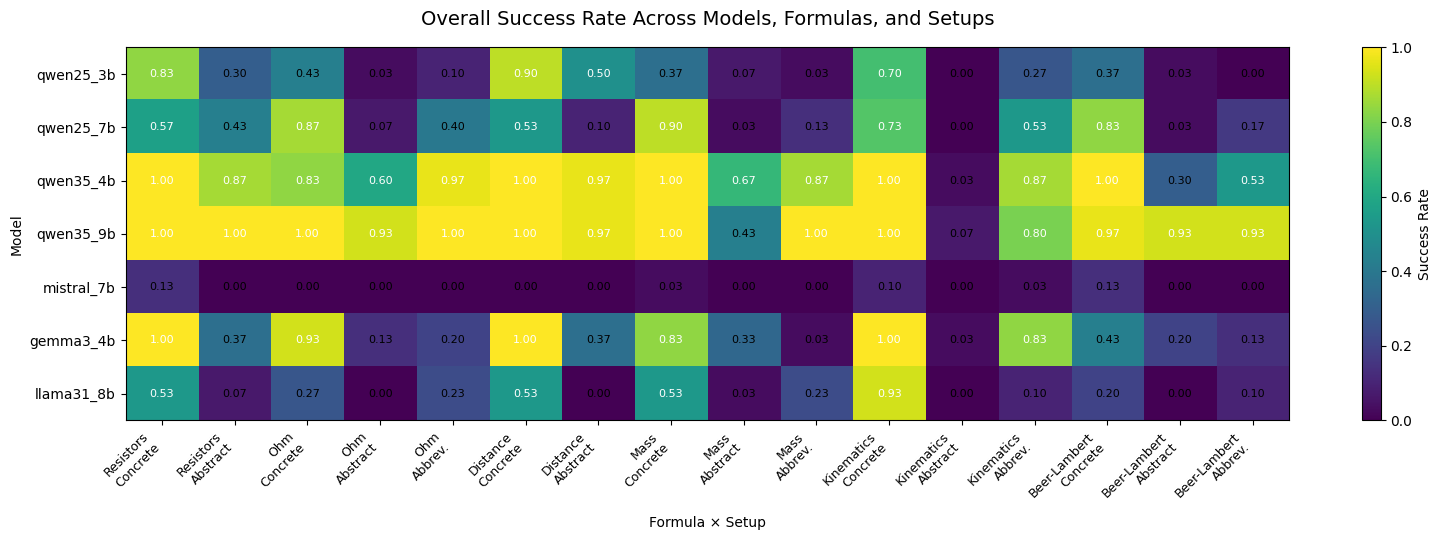

Saved to: figures\overall_performance\overall_success_heatmap.png


In [14]:
fig, ax = plt.subplots(figsize=(16, 5.5))

values = heatmap_df.values
im = ax.imshow(values, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(column_order)))
ax.set_yticks(np.arange(len(model_order)))

x_labels = []
for col in column_order:
    formula, setup = col.split("-", 1)
    x_labels.append(
        f"{formula_label.get(formula, formula)}\n{setup_label.get(setup, setup)}"
    )

ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(model_order, fontsize=10)

ax.set_title(
    "Overall Success Rate Across Models, Formulas, and Setups",
    fontsize=14,
    pad=16,
)
ax.set_xlabel("Formula × Setup")
ax.set_ylabel("Model")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if not np.isnan(value):
            text_color = "white" if value >= 0.5 else "black"
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Success Rate")

plt.tight_layout()

out_path = FIG_DIR / "overall_success_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

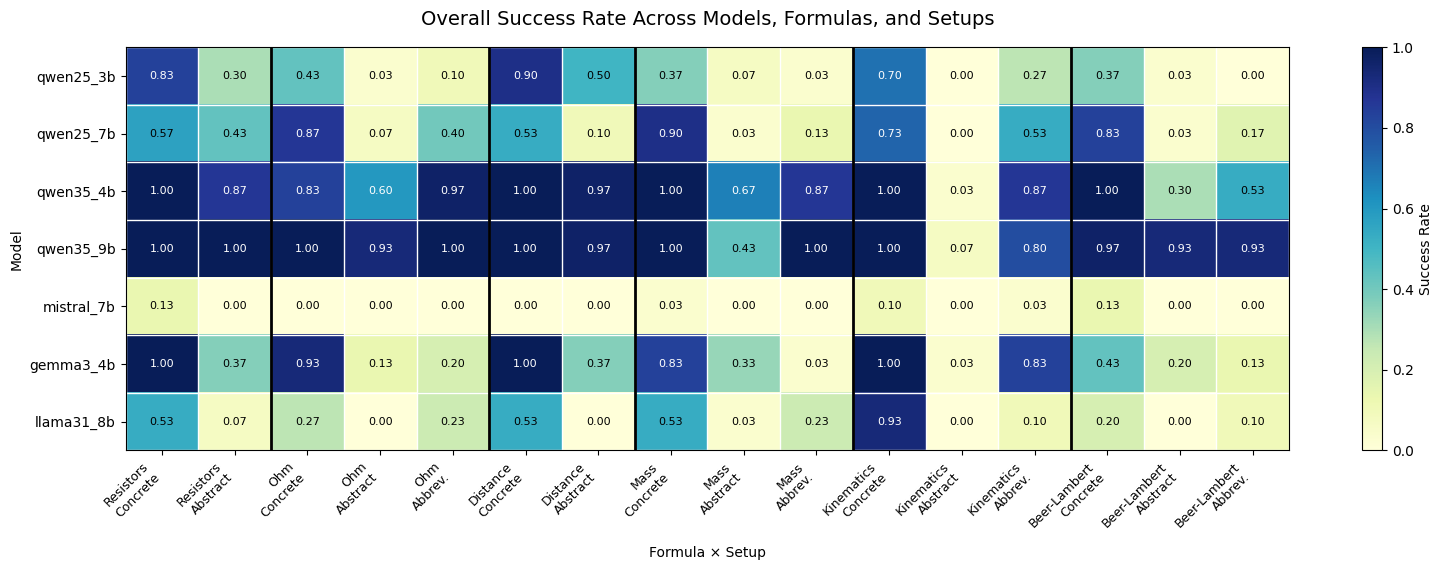

Saved to: figures\overall_performance\overall_success_heatmap_v2.png


In [15]:
fig, ax = plt.subplots(figsize=(16, 5.8))

values = heatmap_df.values

# Recommended colormap: YlGnBu
im = ax.imshow(values, aspect="auto", vmin=0, vmax=1, cmap="YlGnBu")

ax.set_xticks(np.arange(len(column_order)))
ax.set_yticks(np.arange(len(model_order)))

x_labels = []
for col in column_order:
    formula, setup = col.split("-", 1)
    x_labels.append(
        f"{formula_label.get(formula, formula)}\n{setup_label.get(setup, setup)}"
    )

ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(model_order, fontsize=10)

ax.set_title(
    "Overall Success Rate Across Models, Formulas, and Setups",
    fontsize=14,
    pad=16,
)
ax.set_xlabel("Formula × Setup")
ax.set_ylabel("Model")

# ---- Add numeric values inside each cell ----
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if not np.isnan(value):
            # Use white text for dark cells and black text for light cells
            text_color = "white" if value >= 0.6 else "black"
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

# ---- Add thin white grid lines to make cells clearer ----
ax.set_xticks(np.arange(-0.5, len(column_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(model_order), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# ---- Add thicker separators between different formulas ----
# The current column order comes from column_order
# We identify boundaries based on changes in formula names
formula_boundaries = []
prev_formula = None
for idx, col in enumerate(column_order):
    formula, setup = col.split("-", 1)
    if prev_formula is None:
        prev_formula = formula
    elif formula != prev_formula:
        formula_boundaries.append(idx - 0.5)
        prev_formula = formula

for boundary in formula_boundaries:
    ax.axvline(boundary, color="black", linewidth=2)

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Success Rate")

plt.tight_layout()

out_path = FIG_DIR / "overall_success_heatmap_v2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [16]:
model_label = {
    "qwen25_3b": "Qwen2.5-3B",
    "qwen25_7b": "Qwen2.5-7B",
    "qwen35_4b": "Qwen3.5-4B",
    "qwen35_9b": "Qwen3.5-9B",
    "mistral_7b": "Mistral-7B",
    "gemma3_4b": "Gemma3-4B",
    "llama31_8b": "Llama3.1-8B",
}

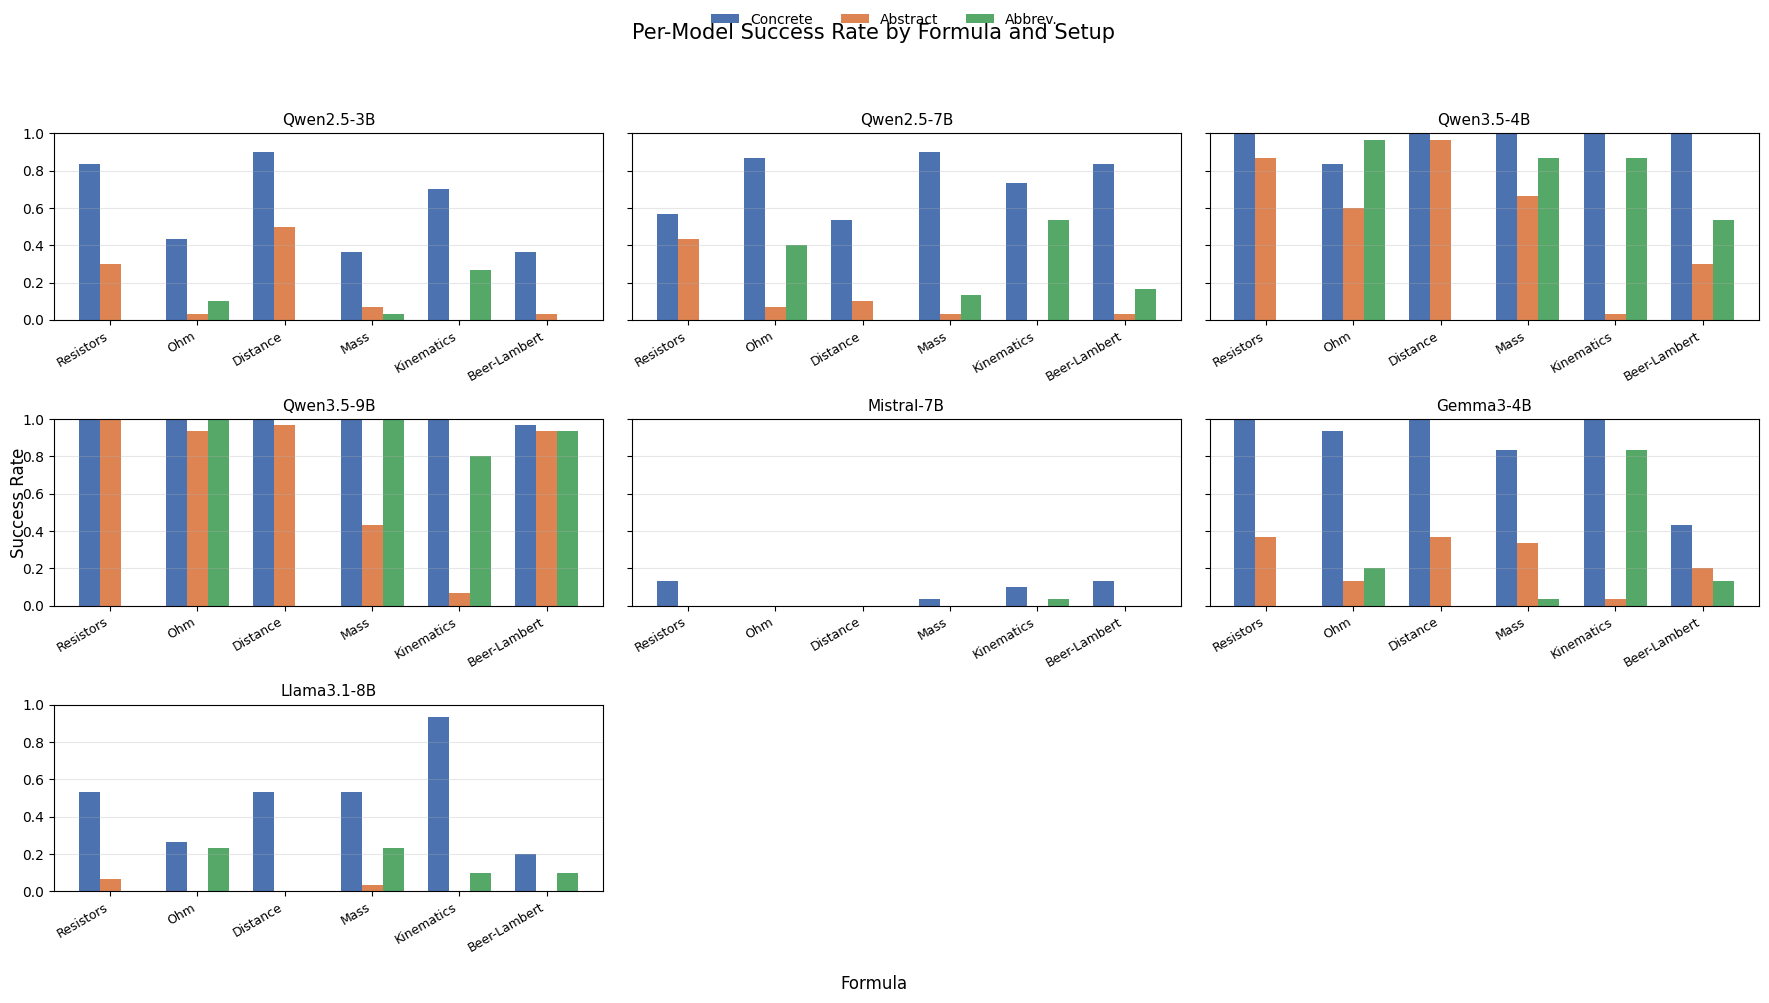

Saved to: figures\overall_performance\faceted_success_bar_chart.png


In [17]:
n_models = len(model_order)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10), sharey=True)
axes = axes.flatten()

x = np.arange(len(formula_order))
bar_width = 0.24

setup_color = {
    "concrete": "#4C72B0",
    "abstract": "#DD8452",
    "abbrev": "#55A868",
}

for ax, model in zip(axes, model_order):
    sub = df[df["model"] == model]

    for offset_idx, setup in enumerate(setup_order):
        setup_sub = (
            sub[sub["setup"] == setup]
            .set_index("formula")
            .reindex(formula_order)
        )

        y = setup_sub["success_rate"].values
        offset = (offset_idx - 1) * bar_width

        # NaN values will not produce visible bars
        ax.bar(
            x + offset,
            y,
            width=bar_width,
            label=setup_label.get(setup, setup),
            color=setup_color.get(setup, None),
        )

    ax.set_title(model_label.get(model, model), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [formula_label.get(f, f) for f in formula_order],
        rotation=30,
        ha="right",
        fontsize=9,
    )
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)

# Turn off unused subplots
for i in range(len(model_order), len(axes)):
    axes[i].axis("off")

# Shared axis labels
fig.supylabel("Success Rate", fontsize=12)
fig.supxlabel("Formula", fontsize=12)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

fig.suptitle("Per-Model Success Rate by Formula and Setup", fontsize=15, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.94])

out_path = FIG_DIR / "faceted_success_bar_chart.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [18]:
PER_MODEL_FIG_DIR = FIG_DIR / "per_model_bar_charts"
PER_MODEL_FIG_DIR.mkdir(parents=True, exist_ok=True)

print(PER_MODEL_FIG_DIR.resolve())

\\wsl.localhost\Ubuntu\home\lly\projects\project\figures\overall_performance\per_model_bar_charts


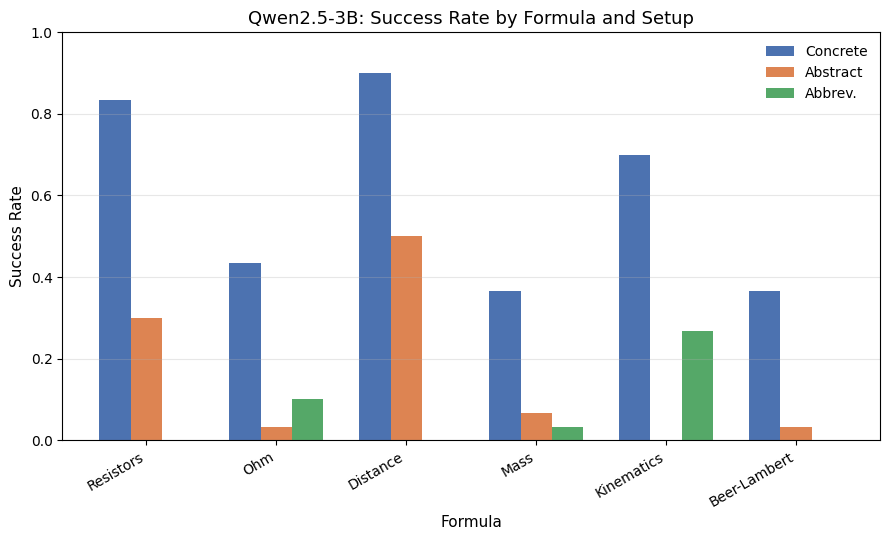

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen25_3b.png


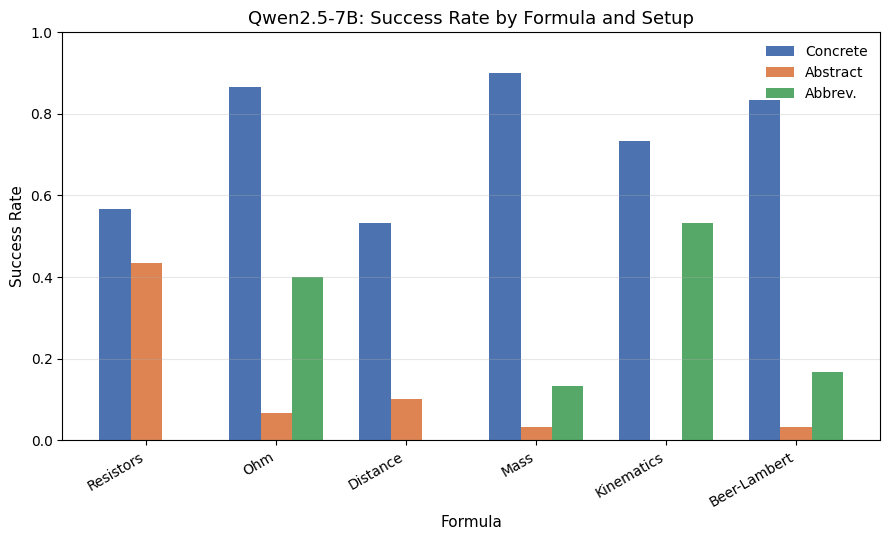

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen25_7b.png


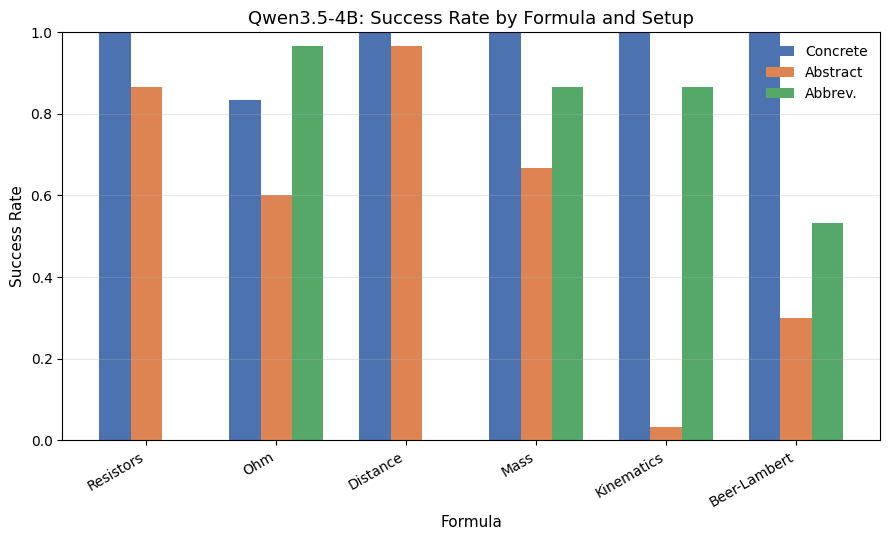

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen35_4b.png


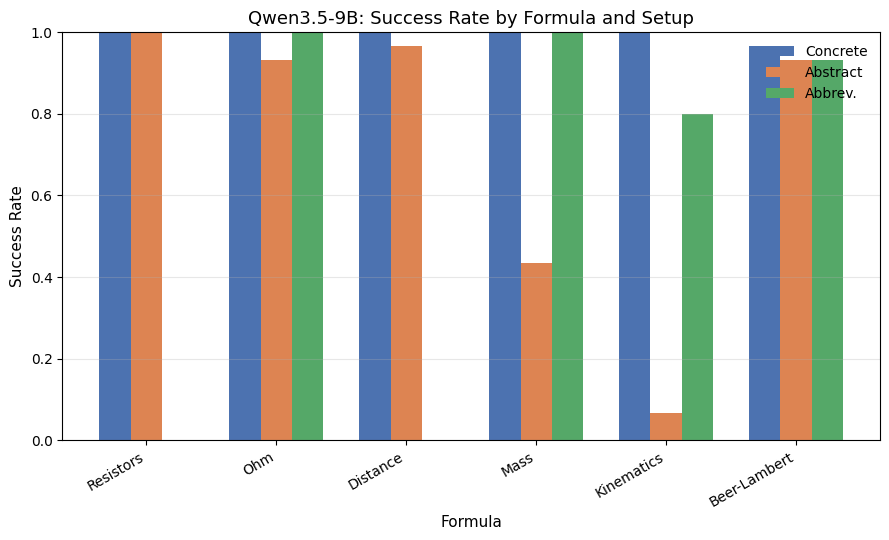

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen35_9b.png


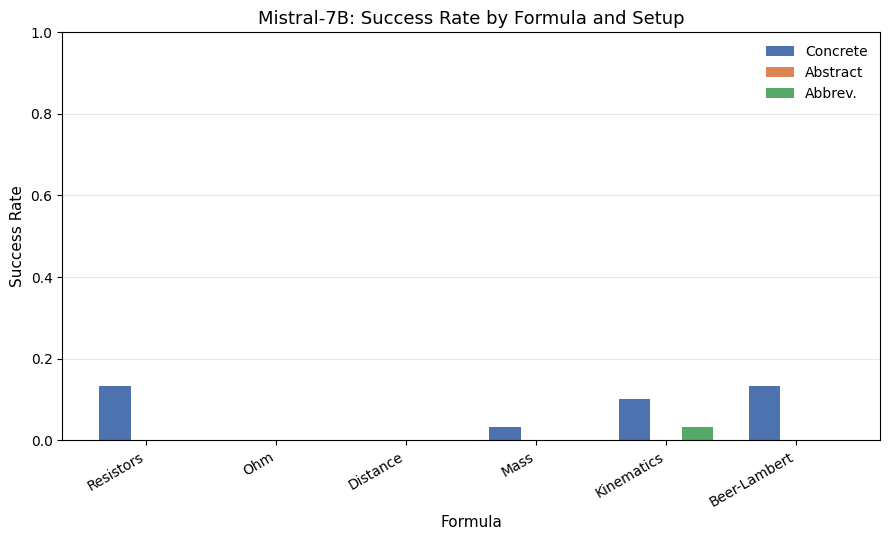

Saved: figures\overall_performance\per_model_bar_charts\success_bar_mistral_7b.png


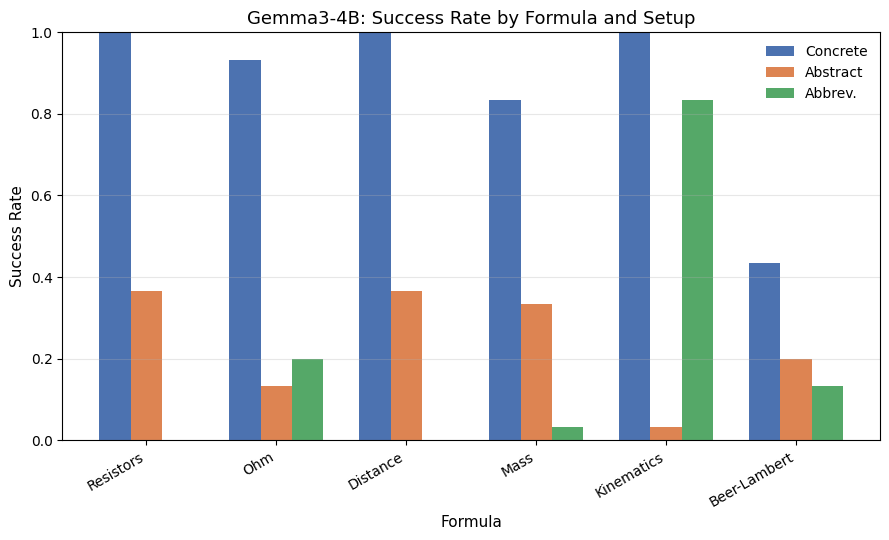

Saved: figures\overall_performance\per_model_bar_charts\success_bar_gemma3_4b.png


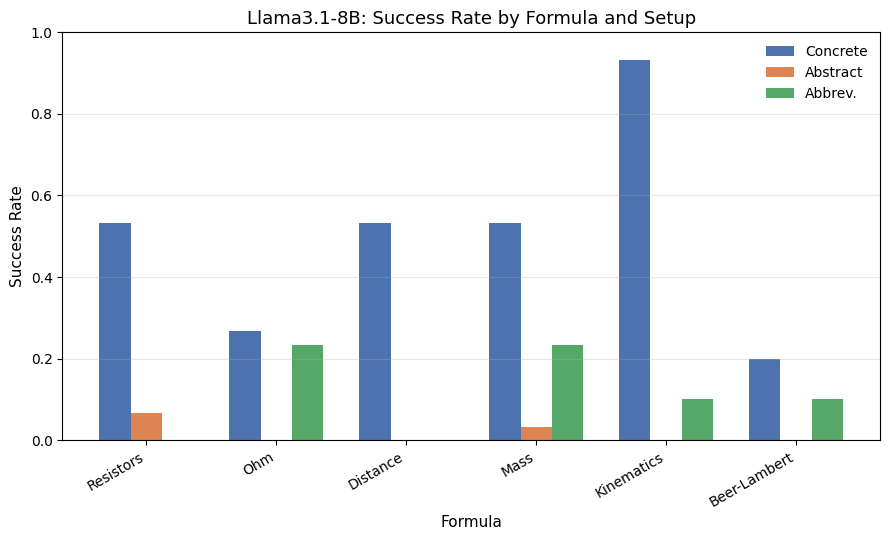

Saved: figures\overall_performance\per_model_bar_charts\success_bar_llama31_8b.png


In [19]:
x = np.arange(len(formula_order))
bar_width = 0.24

saved_paths = []

for model in model_order:
    sub = df[df["model"] == model]

    fig, ax = plt.subplots(figsize=(9, 5.5))

    for offset_idx, setup in enumerate(setup_order):
        setup_sub = (
            sub[sub["setup"] == setup]
            .set_index("formula")
            .reindex(formula_order)
        )

        y = setup_sub["success_rate"].values
        offset = (offset_idx - 1) * bar_width

        # NaN values will not produce visible bars
        ax.bar(
            x + offset,
            y,
            width=bar_width,
            label=setup_label.get(setup, setup),
            color=setup_color.get(setup, None),
        )

    ax.set_title(f"{model_label.get(model, model)}: Success Rate by Formula and Setup", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [formula_label.get(f, f) for f in formula_order],
        rotation=30,
        ha="right",
        fontsize=10,
    )
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Success Rate", fontsize=11)
    ax.set_xlabel("Formula", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()

    out_path = PER_MODEL_FIG_DIR / f"success_bar_{model}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    saved_paths.append(str(out_path))
    print(f"Saved: {out_path}")

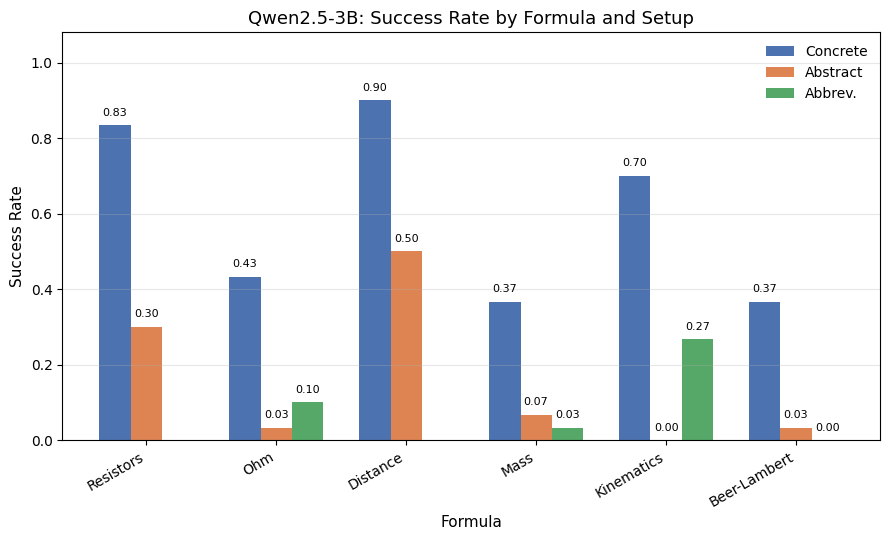

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen25_3b.png


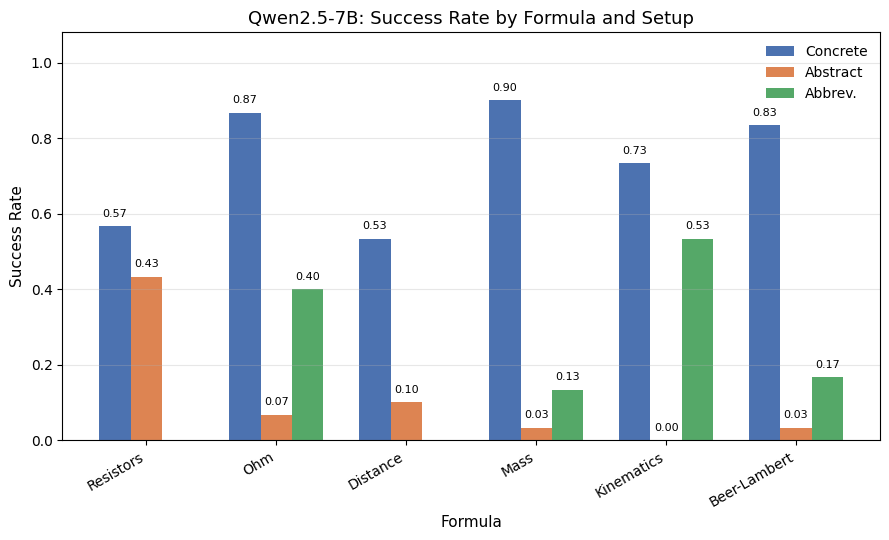

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen25_7b.png


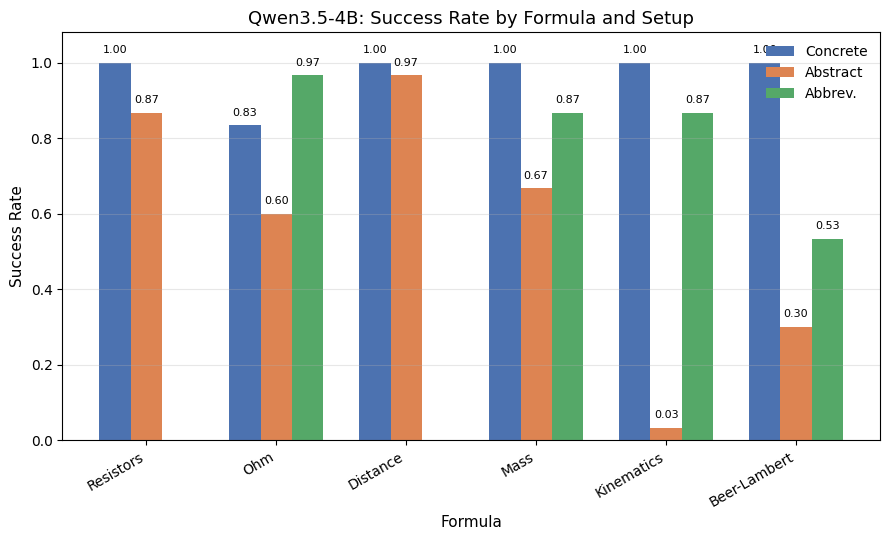

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen35_4b.png


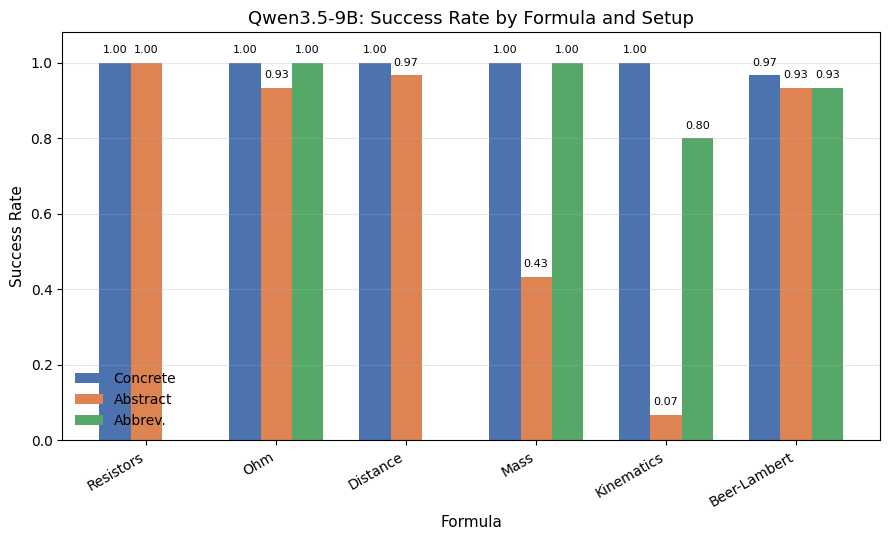

Saved: figures\overall_performance\per_model_bar_charts\success_bar_qwen35_9b.png


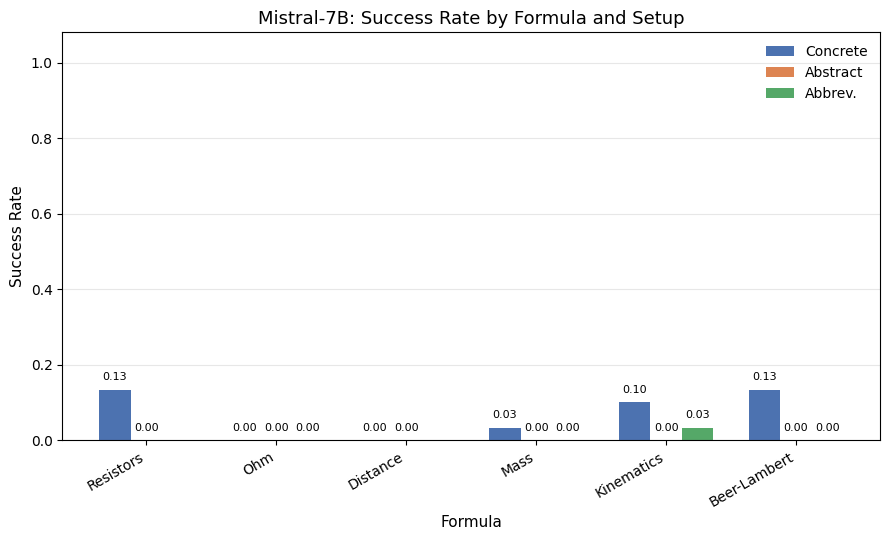

Saved: figures\overall_performance\per_model_bar_charts\success_bar_mistral_7b.png


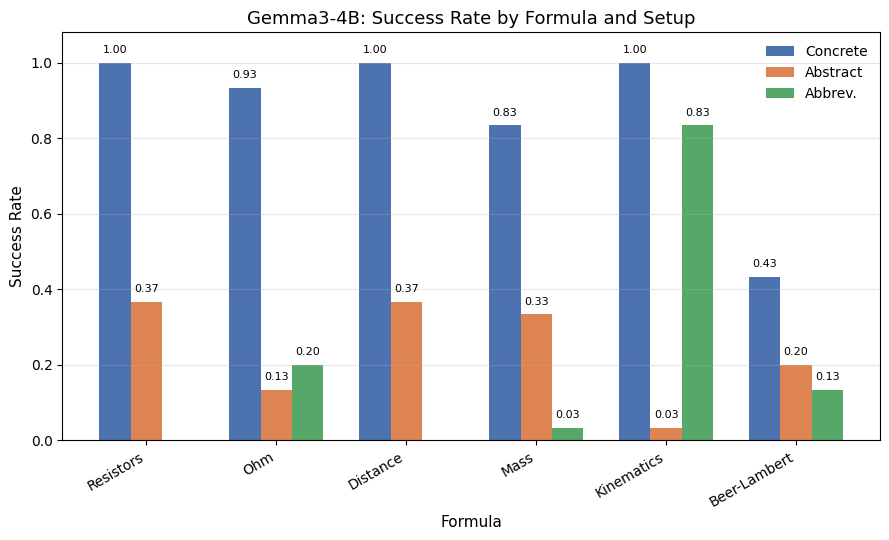

Saved: figures\overall_performance\per_model_bar_charts\success_bar_gemma3_4b.png


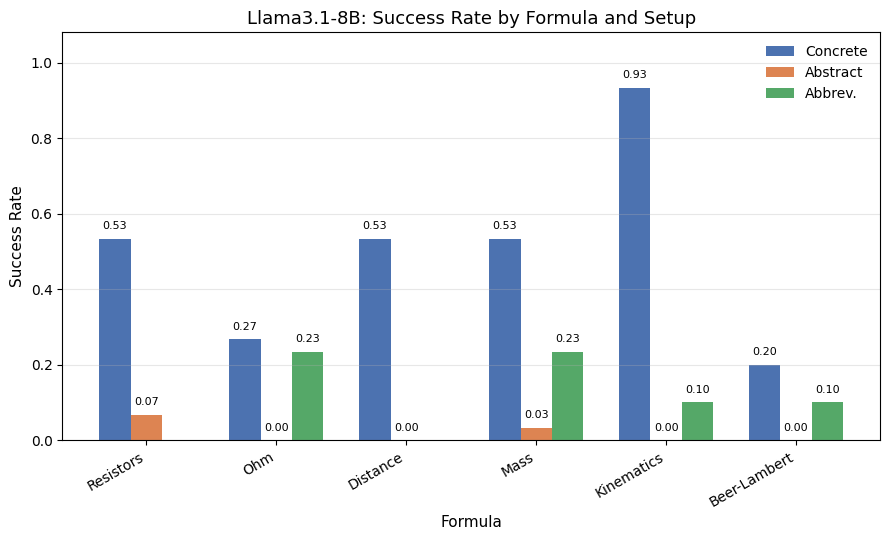

Saved: figures\overall_performance\per_model_bar_charts\success_bar_llama31_8b.png


In [20]:
x = np.arange(len(formula_order))
bar_width = 0.24

saved_paths = []

for model in model_order:
    sub = df[df["model"] == model]

    fig, ax = plt.subplots(figsize=(9, 5.5))

    for offset_idx, setup in enumerate(setup_order):
        setup_sub = (
            sub[sub["setup"] == setup]
            .set_index("formula")
            .reindex(formula_order)
        )

        y = setup_sub["success_rate"].values
        offset = (offset_idx - 1) * bar_width

        bars = ax.bar(
            x + offset,
            y,
            width=bar_width,
            label=setup_label.get(setup, setup),
            color=setup_color.get(setup, None),
        )

        # Add value labels on top of bars
        for bar, val in zip(bars, y):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    ax.set_title(f"{model_label.get(model, model)}: Success Rate by Formula and Setup", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [formula_label.get(f, f) for f in formula_order],
        rotation=30,
        ha="right",
        fontsize=10,
    )
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Success Rate", fontsize=11)
    ax.set_xlabel("Formula", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()

    out_path = PER_MODEL_FIG_DIR / f"success_bar_{model}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    saved_paths.append(str(out_path))
    print(f"Saved: {out_path}")

In [21]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
ROOT = Path("wandb_run_files")
FIG_DIR_02 = Path("figures/failure_modes")
FIG_DIR_02.mkdir(parents=True, exist_ok=True)

model_order = [
    "qwen25_3b",
    "qwen25_7b",
    "qwen35_4b",
    "qwen35_9b",
    "mistral_7b",
    "gemma3_4b",
    "llama31_8b",
]

formula_order = [
    "resistors",
    "ohm",
    "distance",
    "mass",
    "kinematics",
    "beers",
]

setup_order = [
    "concrete",
    "abstract",
    "abbrev",
]

model_label = {
    "qwen25_3b": "Qwen2.5-3B",
    "qwen25_7b": "Qwen2.5-7B",
    "qwen35_4b": "Qwen3.5-4B",
    "qwen35_9b": "Qwen3.5-9B",
    "mistral_7b": "Mistral-7B",
    "gemma3_4b": "Gemma3-4B",
    "llama31_8b": "Llama3.1-8B",
}

In [23]:
def load_failure_mode_data(root: Path) -> pd.DataFrame:
    rows = []

    summary_paths = sorted(root.glob("*/wandb-summary.json"))
    print(f"Found {len(summary_paths)} wandb-summary.json files")

    for summary_path in summary_paths:
        folder_name = summary_path.parent.name

        try:
            parsed = parse_run_folder_name(folder_name)
        except ValueError as e:
            print(f"[SKIP] {e}")
            continue

        with open(summary_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        n_runs = data.get("n_runs", 0)

        tb = data.get("termination_breakdown", {})
        finish_success = tb.get("finish_success", 0)
        finish_wrong = tb.get("finish_wrong", 0)
        max_steps = tb.get("max_steps", 0)
        parse_error = tb.get("parse_error", 0)

        rows.append({
            "folder_name": folder_name,
            "summary_path": str(summary_path),
            "formula": parsed["formula"],
            "setup": parsed["setup"],
            "model": parsed["model"],
            "n_runs": n_runs,
            "finish_success": finish_success,
            "finish_wrong": finish_wrong,
            "max_steps": max_steps,
            "parse_error": parse_error,
        })

    df_fail = pd.DataFrame(rows)
    return df_fail

In [24]:
df_fail = load_failure_mode_data(ROOT)
print(df_fail.shape)
display(df_fail.head())

Found 113 wandb-summary.json files
(113, 10)


,folder_name,summary_path,formula,setup,model,n_runs,finish_success,finish_wrong,max_steps,parse_error
0,beers_abbrev_gemma3_4b__1u7mfx02,wandb_run_files\beers_abbrev_gemma3_4b__1u7mfx...,beers,abbrev,gemma3_4b,30,4,26,0,0
1,beers_abbrev_llama31_8b__yfd03aqb,wandb_run_files\beers_abbrev_llama31_8b__yfd03...,beers,abbrev,llama31_8b,30,3,24,2,1
2,beers_abbrev_mistral_7b__qbfm1ooe,wandb_run_files\beers_abbrev_mistral_7b__qbfm1...,beers,abbrev,mistral_7b,30,0,9,0,21
3,beers_abbrev_qwen25_3b__e92pesmg,wandb_run_files\beers_abbrev_qwen25_3b__e92pes...,beers,abbrev,qwen25_3b,30,0,28,0,2
4,beers_abbrev_qwen25_7b__sofb46aj,wandb_run_files\beers_abbrev_qwen25_7b__sofb46...,beers,abbrev,qwen25_7b,30,5,25,0,0


In [25]:
df_fail["breakdown_sum"] = (
    df_fail["finish_success"]
    + df_fail["finish_wrong"]
    + df_fail["max_steps"]
    + df_fail["parse_error"]
)

display(
    df_fail[
        ["model", "formula", "setup", "n_runs", "breakdown_sum"]
    ].head(10)
)

print("Any mismatch between n_runs and breakdown_sum?")
print((df_fail["n_runs"] != df_fail["breakdown_sum"]).sum())

,model,formula,setup,n_runs,breakdown_sum
0,gemma3_4b,beers,abbrev,30,30
1,llama31_8b,beers,abbrev,30,30
2,mistral_7b,beers,abbrev,30,30
3,qwen25_3b,beers,abbrev,30,30
4,qwen25_7b,beers,abbrev,30,30
5,qwen35_4b,beers,abbrev,30,30
6,qwen35_9b,beers,abbrev,30,30
7,gemma3_4b,beers,abstract,30,30
8,llama31_8b,beers,abstract,30,30
9,mistral_7b,beers,abstract,30,30


Any mismatch between n_runs and breakdown_sum?
0


In [26]:
df_fail_model = (
    df_fail
    .groupby("model", as_index=False)[
        ["n_runs", "finish_success", "finish_wrong", "max_steps", "parse_error"]
    ]
    .sum()
)

df_fail_model["finish_success_rate"] = df_fail_model["finish_success"] / df_fail_model["n_runs"]
df_fail_model["finish_wrong_rate"] = df_fail_model["finish_wrong"] / df_fail_model["n_runs"]
df_fail_model["max_steps_rate"] = df_fail_model["max_steps"] / df_fail_model["n_runs"]
df_fail_model["parse_error_rate"] = df_fail_model["parse_error"] / df_fail_model["n_runs"]

df_fail_model["model"] = pd.Categorical(
    df_fail_model["model"], categories=model_order, ordered=True
)
df_fail_model = df_fail_model.sort_values("model").reset_index(drop=True)

display(df_fail_model)

,model,n_runs,finish_success,finish_wrong,max_steps,parse_error,finish_success_rate,finish_wrong_rate,max_steps_rate,parse_error_rate
0,qwen25_3b,480,148,307,0,25,0.308333,0.639583,0.00000,0.052083
1,qwen25_7b,480,190,272,0,18,0.395833,0.566667,0.00000,0.037500
2,qwen35_4b,480,375,49,0,56,0.781250,0.102083,0.00000,0.116667
3,qwen35_9b,480,421,38,0,21,0.877083,0.079167,0.00000,0.043750
4,mistral_7b,480,13,72,0,395,0.027083,0.150000,0.00000,0.822917
5,gemma3_4b,480,235,245,0,0,0.489583,0.510417,0.00000,0.000000
6,llama31_8b,480,113,310,39,18,0.235417,0.645833,0.08125,0.037500


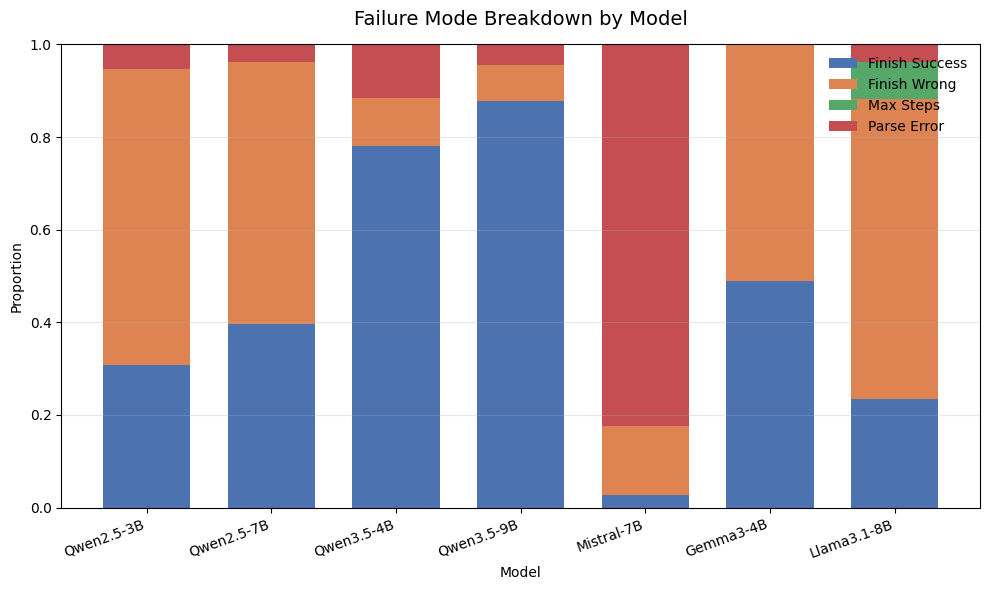

Saved to: figures\failure_modes\failure_mode_breakdown_by_model.png


In [27]:
failure_color = {
    "finish_success_rate": "#4C72B0",  # blue
    "finish_wrong_rate": "#DD8452",    # orange
    "max_steps_rate": "#55A868",       # green
    "parse_error_rate": "#C44E52",     # red
}

failure_label = {
    "finish_success_rate": "Finish Success",
    "finish_wrong_rate": "Finish Wrong",
    "max_steps_rate": "Max Steps",
    "parse_error_rate": "Parse Error",
}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_fail_model))
bottom = np.zeros(len(df_fail_model))

stack_order = [
    "finish_success_rate",
    "finish_wrong_rate",
    "max_steps_rate",
    "parse_error_rate",
]

for col in stack_order:
    vals = df_fail_model[col].values
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=failure_label[col],
        color=failure_color[col],
        width=0.7,
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(
    [model_label.get(m, m) for m in df_fail_model["model"]],
    rotation=20,
    ha="right",
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Proportion")
ax.set_xlabel("Model")
ax.set_title("Failure Mode Breakdown by Model", fontsize=14, pad=14)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()

out_path = FIG_DIR_02 / "failure_mode_breakdown_by_model.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

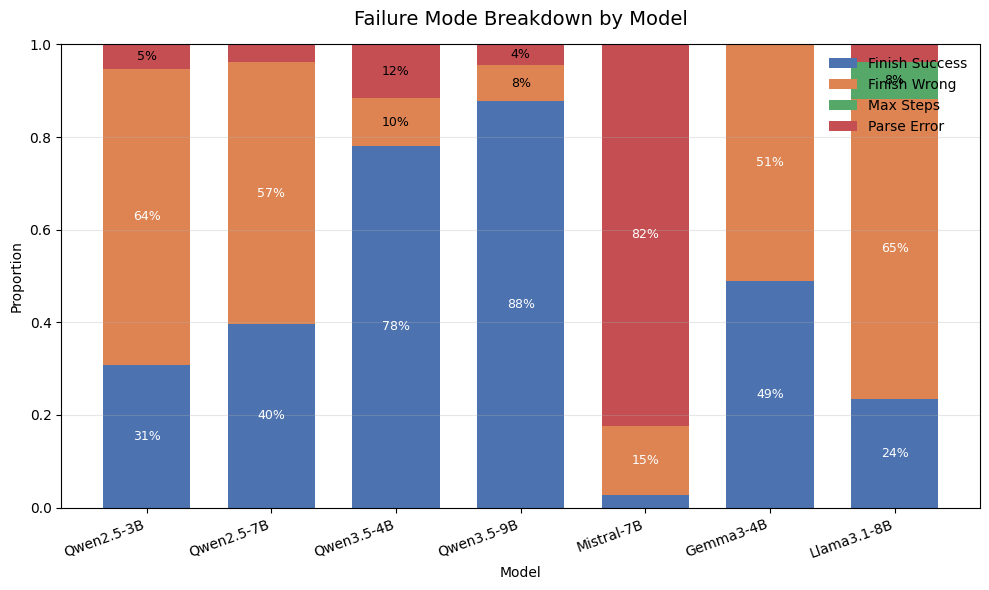

Saved to: figures\failure_modes\failure_mode_breakdown_by_model_labeled.png


In [28]:
failure_color = {
    "finish_success_rate": "#4C72B0",  # blue
    "finish_wrong_rate": "#DD8452",    # orange
    "max_steps_rate": "#55A868",       # green
    "parse_error_rate": "#C44E52",     # red
}

failure_label = {
    "finish_success_rate": "Finish Success",
    "finish_wrong_rate": "Finish Wrong",
    "max_steps_rate": "Max Steps",
    "parse_error_rate": "Parse Error",
}

stack_order = [
    "finish_success_rate",
    "finish_wrong_rate",
    "max_steps_rate",
    "parse_error_rate",
]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_fail_model))
bottom = np.zeros(len(df_fail_model))

for col in stack_order:
    vals = df_fail_model[col].values

    bars = ax.bar(
        x,
        vals,
        bottom=bottom,
        label=failure_label[col],
        color=failure_color[col],
        width=0.7,
    )

    # Add value labels inside each stacked segment
    for i, (bar, val, btm) in enumerate(zip(bars, vals, bottom)):
        if val >= 0.04:  # only label segments large enough to be readable
            y = btm + val / 2
            text_color = "white" if val >= 0.12 else "black"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{val:.0%}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
            )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(
    [model_label.get(m, m) for m in df_fail_model["model"]],
    rotation=20,
    ha="right",
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Proportion")
ax.set_xlabel("Model")
ax.set_title("Failure Mode Breakdown by Model", fontsize=14, pad=14)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()

out_path = FIG_DIR_02 / "failure_mode_breakdown_by_model_labeled.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [29]:
df_fail_setup = (
    df_fail
    .groupby("setup", as_index=False)[
        ["n_runs", "finish_success", "finish_wrong", "max_steps", "parse_error"]
    ]
    .sum()
)

df_fail_setup["finish_success_rate"] = df_fail_setup["finish_success"] / df_fail_setup["n_runs"]
df_fail_setup["finish_wrong_rate"] = df_fail_setup["finish_wrong"] / df_fail_setup["n_runs"]
df_fail_setup["max_steps_rate"] = df_fail_setup["max_steps"] / df_fail_setup["n_runs"]
df_fail_setup["parse_error_rate"] = df_fail_setup["parse_error"] / df_fail_setup["n_runs"]

df_fail_setup["setup"] = pd.Categorical(
    df_fail_setup["setup"], categories=setup_order, ordered=True
)
df_fail_setup = df_fail_setup.sort_values("setup").reset_index(drop=True)

display(df_fail_setup)

,setup,n_runs,finish_success,finish_wrong,max_steps,parse_error,finish_success_rate,finish_wrong_rate,max_steps_rate,parse_error_rate
0,concrete,1260,853,215,6,186,0.676984,0.170635,0.004762,0.147619
1,abstract,1260,327,686,24,223,0.259524,0.544444,0.019048,0.176984
2,abbrev,840,315,392,9,124,0.375000,0.466667,0.010714,0.147619


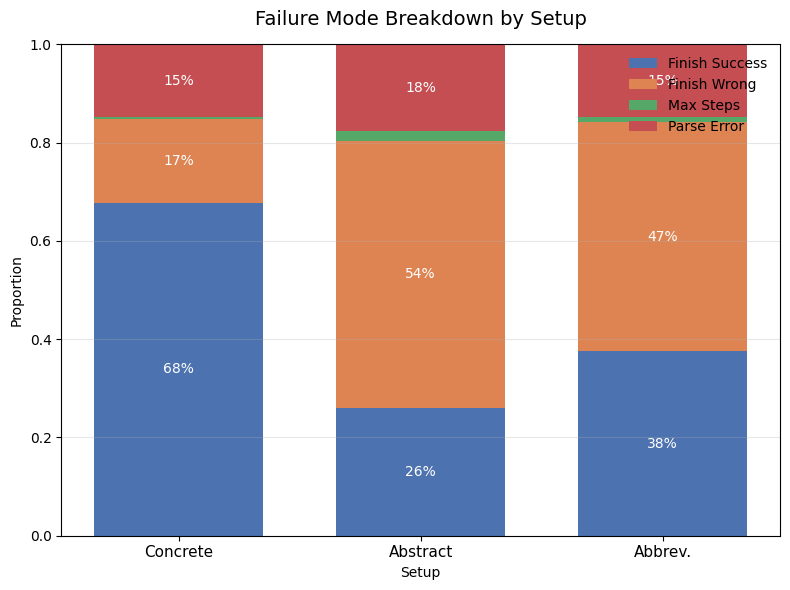

Saved to: figures\failure_modes\failure_mode_breakdown_by_setup.png


In [30]:
failure_color = {
    "finish_success_rate": "#4C72B0",  # blue
    "finish_wrong_rate": "#DD8452",    # orange
    "max_steps_rate": "#55A868",       # green
    "parse_error_rate": "#C44E52",     # red
}

failure_label = {
    "finish_success_rate": "Finish Success",
    "finish_wrong_rate": "Finish Wrong",
    "max_steps_rate": "Max Steps",
    "parse_error_rate": "Parse Error",
}

stack_order = [
    "finish_success_rate",
    "finish_wrong_rate",
    "max_steps_rate",
    "parse_error_rate",
]

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df_fail_setup))
bottom = np.zeros(len(df_fail_setup))

for col in stack_order:
    vals = df_fail_setup[col].values

    bars = ax.bar(
        x,
        vals,
        bottom=bottom,
        label=failure_label[col],
        color=failure_color[col],
        width=0.7,
    )

    # Add value labels inside each stacked segment
    for bar, val, btm in zip(bars, vals, bottom):
        if val >= 0.04:
            y = btm + val / 2
            text_color = "white" if val >= 0.12 else "black"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{val:.0%}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
            )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([setup_label.get(s, s) for s in df_fail_setup["setup"]], fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Proportion")
ax.set_xlabel("Setup")
ax.set_title("Failure Mode Breakdown by Setup", fontsize=14, pad=14)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()

out_path = FIG_DIR_02 / "failure_mode_breakdown_by_setup.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [31]:
df_fail_formula = (
    df_fail
    .groupby("formula", as_index=False)[
        ["n_runs", "finish_success", "finish_wrong", "max_steps", "parse_error"]
    ]
    .sum()
)

df_fail_formula["finish_success_rate"] = df_fail_formula["finish_success"] / df_fail_formula["n_runs"]
df_fail_formula["finish_wrong_rate"] = df_fail_formula["finish_wrong"] / df_fail_formula["n_runs"]
df_fail_formula["max_steps_rate"] = df_fail_formula["max_steps"] / df_fail_formula["n_runs"]
df_fail_formula["parse_error_rate"] = df_fail_formula["parse_error"] / df_fail_formula["n_runs"]

df_fail_formula["formula"] = pd.Categorical(
    df_fail_formula["formula"], categories=formula_order, ordered=True
)
df_fail_formula = df_fail_formula.sort_values("formula").reset_index(drop=True)

display(df_fail_formula)

,formula,n_runs,finish_success,finish_wrong,max_steps,parse_error,finish_success_rate,finish_wrong_rate,max_steps_rate,parse_error_rate
0,resistors,420,243,118,9,50,0.578571,0.280952,0.021429,0.119048
1,ohm,630,270,267,8,85,0.428571,0.423810,0.012698,0.134921
2,distance,420,236,104,7,73,0.561905,0.247619,0.016667,0.173810
3,mass,630,256,256,6,112,0.406349,0.406349,0.009524,0.177778
4,kinematics,630,271,232,6,121,0.430159,0.368254,0.009524,0.192063
5,beers,630,219,316,3,92,0.347619,0.501587,0.004762,0.146032


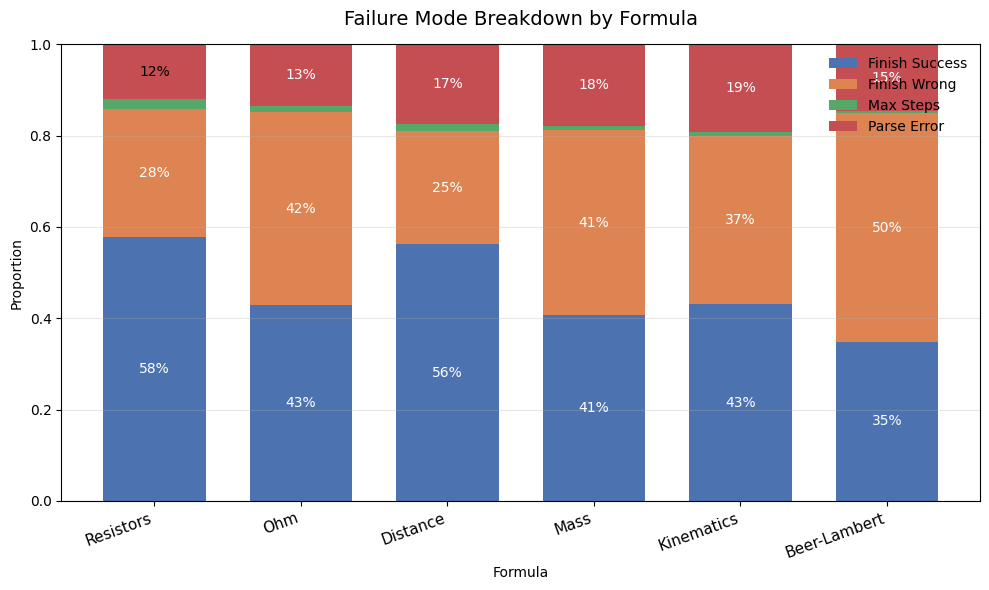

Saved to: figures\failure_modes\failure_mode_breakdown_by_formula.png


In [32]:
failure_color = {
    "finish_success_rate": "#4C72B0",  # blue
    "finish_wrong_rate": "#DD8452",    # orange
    "max_steps_rate": "#55A868",       # green
    "parse_error_rate": "#C44E52",     # red
}

failure_label = {
    "finish_success_rate": "Finish Success",
    "finish_wrong_rate": "Finish Wrong",
    "max_steps_rate": "Max Steps",
    "parse_error_rate": "Parse Error",
}

stack_order = [
    "finish_success_rate",
    "finish_wrong_rate",
    "max_steps_rate",
    "parse_error_rate",
]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_fail_formula))
bottom = np.zeros(len(df_fail_formula))

for col in stack_order:
    vals = df_fail_formula[col].values

    bars = ax.bar(
        x,
        vals,
        bottom=bottom,
        label=failure_label[col],
        color=failure_color[col],
        width=0.7,
    )

    # Add value labels inside each stacked segment
    for bar, val, btm in zip(bars, vals, bottom):
        if val >= 0.04:
            y = btm + val / 2
            text_color = "white" if val >= 0.12 else "black"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{val:.0%}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
            )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(
    [formula_label.get(f, f) for f in df_fail_formula["formula"]],
    rotation=20,
    ha="right",
    fontsize=11,
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Proportion")
ax.set_xlabel("Formula")
ax.set_title("Failure Mode Breakdown by Formula", fontsize=14, pad=14)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()

out_path = FIG_DIR_02 / "failure_mode_breakdown_by_formula.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [33]:
def parse_run_folder_name(folder_name: str) -> dict:
    """
    Parse folder names like:
    distance_abstract_gemma3_4b__stzy25x3
    ohm_abbrev_qwen25_7b__abcd1234
    """
    clean_name = folder_name.split("__")[0]
    parts = clean_name.split("_")

    setup_candidates = {"concrete", "abstract", "abbrev", "abbreviated"}

    setup_idx = None
    for i, part in enumerate(parts):
        if part in setup_candidates:
            setup_idx = i
            break

    if setup_idx is None:
        raise ValueError(f"Cannot find setup in folder name: {folder_name}")

    formula = "_".join(parts[:setup_idx])
    setup = parts[setup_idx]
    model = "_".join(parts[setup_idx + 1:])

    if setup == "abbreviated":
        setup = "abbrev"

    return {
        "formula": formula,
        "setup": setup,
        "model": model,
    }

In [36]:
def parse_run_folder_name(folder_name: str) -> dict:
    """
    Parse folder names like:
    distance_abstract_gemma3_4b__stzy25x3
    ohm_abbrev_qwen25_7b__abcd1234
    """
    clean_name = folder_name.split("__")[0]
    parts = clean_name.split("_")

    setup_candidates = {"concrete", "abstract", "abbrev", "abbreviated"}

    setup_idx = None
    for i, part in enumerate(parts):
        if part in setup_candidates:
            setup_idx = i
            break

    if setup_idx is None:
        raise ValueError(f"Cannot find setup in folder name: {folder_name}")

    formula = "_".join(parts[:setup_idx])
    setup = parts[setup_idx]
    model = "_".join(parts[setup_idx + 1:])

    if setup == "abbreviated":
        setup = "abbrev"

    return {
        "formula": formula,
        "setup": setup,
        "model": model,
    }

In [37]:
def load_success_table(root: Path) -> pd.DataFrame:
    rows = []

    summary_paths = sorted(root.glob("*/wandb-summary.json"))
    print(f"Found {len(summary_paths)} wandb-summary.json files")

    for summary_path in summary_paths:
        folder_name = summary_path.parent.name

        try:
            parsed = parse_run_folder_name(folder_name)
        except ValueError as e:
            print(f"[SKIP] {e}")
            continue

        with open(summary_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        rows.append({
            "folder_name": folder_name,
            "summary_path": str(summary_path),
            "formula": parsed["formula"],
            "setup": parsed["setup"],
            "model": parsed["model"],
            "success_rate": float(data.get("success_rate", np.nan)),
            "n_runs": data.get("n_runs", np.nan),
        })

    df = pd.DataFrame(rows)

    df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
    df["formula"] = pd.Categorical(df["formula"], categories=formula_order, ordered=True)
    df["setup"] = pd.Categorical(df["setup"], categories=setup_order, ordered=True)

    df = df.sort_values(["model", "formula", "setup"]).reset_index(drop=True)
    return df

In [38]:
df = load_success_table(ROOT)
print(df.shape)
display(df.head())

Found 113 wandb-summary.json files
(113, 7)


,folder_name,summary_path,formula,setup,model,success_rate,n_runs
0,resistors_concrete_qwen25_3b__7i3lwokj,wandb_run_files\resistors_concrete_qwen25_3b__...,resistors,concrete,qwen25_3b,0.833333,30.0
1,resistors_abstract_qwen25_3b__62p28dog,wandb_run_files\resistors_abstract_qwen25_3b__...,resistors,abstract,qwen25_3b,0.300000,30.0
2,ohm_concrete_qwen25_3b__ktebi5qx,wandb_run_files\ohm_concrete_qwen25_3b__ktebi5...,ohm,concrete,qwen25_3b,0.433333,30.0
3,ohm_abstract_qwen25_3b__499ontvs,wandb_run_files\ohm_abstract_qwen25_3b__499ont...,ohm,abstract,qwen25_3b,0.033333,30.0
4,ohm_abbrev_qwen25_3b__skzxlqaa,wandb_run_files\ohm_abbrev_qwen25_3b__skzxlqaa...,ohm,abbrev,qwen25_3b,0.100000,30.0


In [39]:
pivot_setup = (
    df.pivot_table(
        index=["model", "formula"],
        columns="setup",
        values="success_rate"
    )
    .reset_index()
)

pivot_setup["delta_concrete_vs_abstract"] = (
    pivot_setup["concrete"] - pivot_setup["abstract"]
)

display(pivot_setup.head())

setup,model,formula,concrete,abstract,abbrev,delta_concrete_vs_abstract
0,qwen25_3b,resistors,0.833333,0.300000,NaN,0.533333
1,qwen25_3b,ohm,0.433333,0.033333,0.100000,0.400000
2,qwen25_3b,distance,0.900000,0.500000,NaN,0.400000
3,qwen25_3b,mass,0.366667,0.066667,0.033333,0.300000
4,qwen25_3b,kinematics,0.700000,0.000000,0.266667,0.700000


In [40]:
delta_concrete_df = (
    pivot_setup
    .pivot(index="model", columns="formula", values="delta_concrete_vs_abstract")
    .reindex(index=model_order, columns=formula_order)
)

display(delta_concrete_df)

formula,resistors,ohm,distance,mass,kinematics,beers
model,,,,,,
qwen25_3b,0.533333,0.400000,0.400000,0.300000,0.700000,0.333333
qwen25_7b,0.133333,0.800000,0.433333,0.866667,0.733333,0.800000
qwen35_4b,0.133333,0.233333,0.033333,0.333333,0.966667,0.700000
qwen35_9b,0.000000,0.066667,0.033333,0.566667,0.933333,0.033333
mistral_7b,0.133333,0.000000,0.000000,0.033333,0.100000,0.133333
gemma3_4b,0.633333,0.800000,0.633333,0.500000,0.966667,0.233333
llama31_8b,0.466667,0.266667,0.533333,0.500000,0.933333,0.200000


NameError: name 'FIG_DIR_04' is not defined

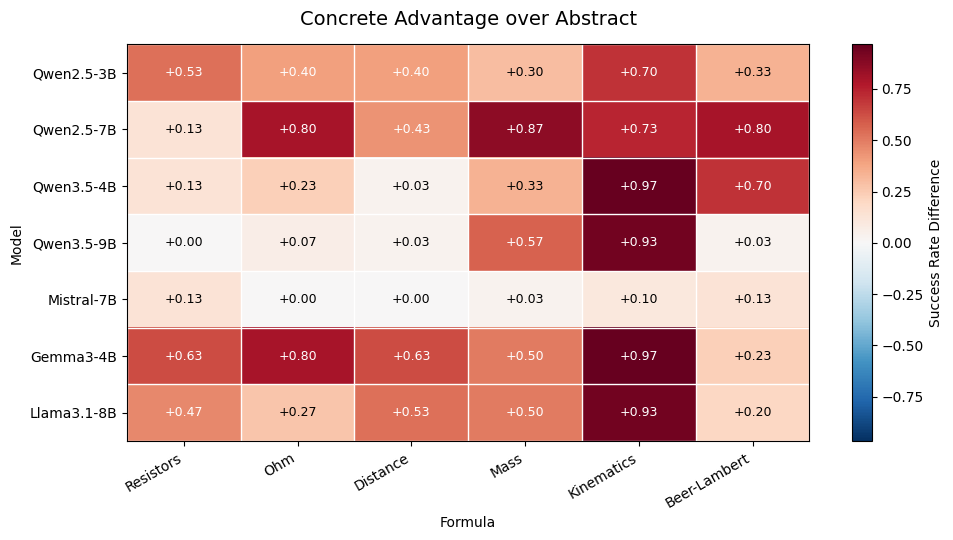

In [41]:
fig, ax = plt.subplots(figsize=(10, 5.5))

values = delta_concrete_df.values

# Diverging colormap centered at 0
vmax = np.nanmax(np.abs(values))
im = ax.imshow(values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(formula_order)))
ax.set_yticks(np.arange(len(model_order)))

ax.set_xticklabels(
    [formula_label.get(f, f) for f in formula_order],
    rotation=30,
    ha="right",
    fontsize=10,
)
ax.set_yticklabels(
    [model_label.get(m, m) for m in model_order],
    fontsize=10,
)

ax.set_title("Concrete Advantage over Abstract", fontsize=14, pad=14)
ax.set_xlabel("Formula")
ax.set_ylabel("Model")

# Add cell values
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if not np.isnan(value):
            text_color = "white" if abs(value) >= 0.35 else "black"
            ax.text(
                j,
                i,
                f"{value:+.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
            )

# Add cell borders
ax.set_xticks(np.arange(-0.5, len(formula_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(model_order), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Success Rate Difference")

plt.tight_layout()

out_path = FIG_DIR_04 / "delta_concrete_vs_abstract_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [42]:
pivot_setup["delta_abbrev_vs_abstract"] = (
    pivot_setup["abbrev"] - pivot_setup["abstract"]
)

delta_abbrev_df = (
    pivot_setup
    .pivot(index="model", columns="formula", values="delta_abbrev_vs_abstract")
    .reindex(index=model_order, columns=formula_order)
)

display(delta_abbrev_df)

formula,resistors,ohm,distance,mass,kinematics,beers
model,,,,,,
qwen25_3b,NaN,0.066667,NaN,-0.033333,0.266667,-0.033333
qwen25_7b,NaN,0.333333,NaN,0.100000,0.533333,0.133333
qwen35_4b,NaN,0.366667,NaN,0.200000,0.833333,0.233333
qwen35_9b,NaN,0.066667,NaN,0.566667,0.733333,0.000000
mistral_7b,NaN,0.000000,NaN,0.000000,0.033333,0.000000
gemma3_4b,NaN,0.066667,NaN,-0.300000,0.800000,-0.066667
llama31_8b,NaN,0.233333,NaN,0.200000,0.100000,0.100000


NameError: name 'FIG_DIR_04' is not defined

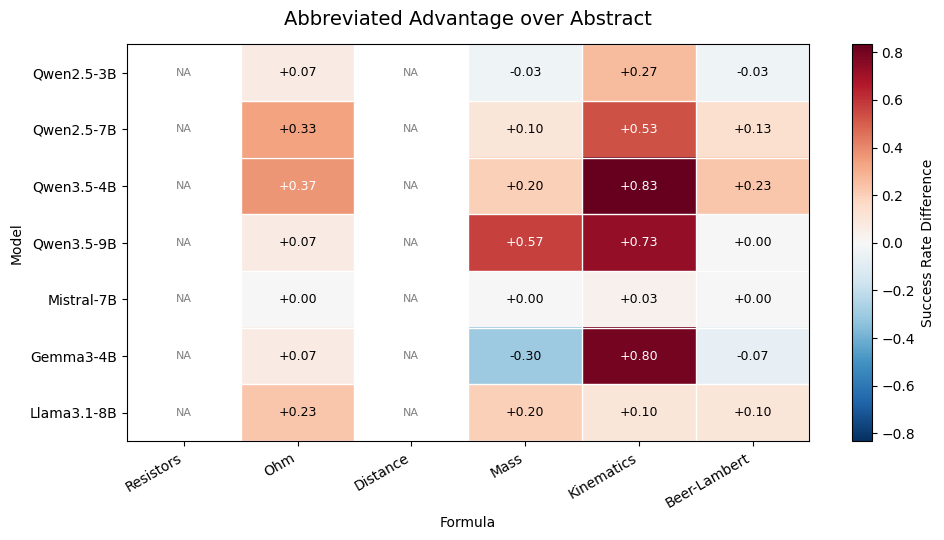

In [43]:
fig, ax = plt.subplots(figsize=(10, 5.5))

values = delta_abbrev_df.values

vmax = np.nanmax(np.abs(values))
im = ax.imshow(values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(formula_order)))
ax.set_yticks(np.arange(len(model_order)))

ax.set_xticklabels(
    [formula_label.get(f, f) for f in formula_order],
    rotation=30,
    ha="right",
    fontsize=10,
)
ax.set_yticklabels(
    [model_label.get(m, m) for m in model_order],
    fontsize=10,
)

ax.set_title("Abbreviated Advantage over Abstract", fontsize=14, pad=14)
ax.set_xlabel("Formula")
ax.set_ylabel("Model")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if not np.isnan(value):
            text_color = "white" if abs(value) >= 0.35 else "black"
            ax.text(
                j,
                i,
                f"{value:+.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
            )
        else:
            ax.text(
                j,
                i,
                "NA",
                ha="center",
                va="center",
                fontsize=8,
                color="gray",
            )

ax.set_xticks(np.arange(-0.5, len(formula_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(model_order), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Success Rate Difference")

plt.tight_layout()

out_path = FIG_DIR_04 / "delta_abbrev_vs_abstract_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

ValueError: cannot reindex on an axis with duplicate labels

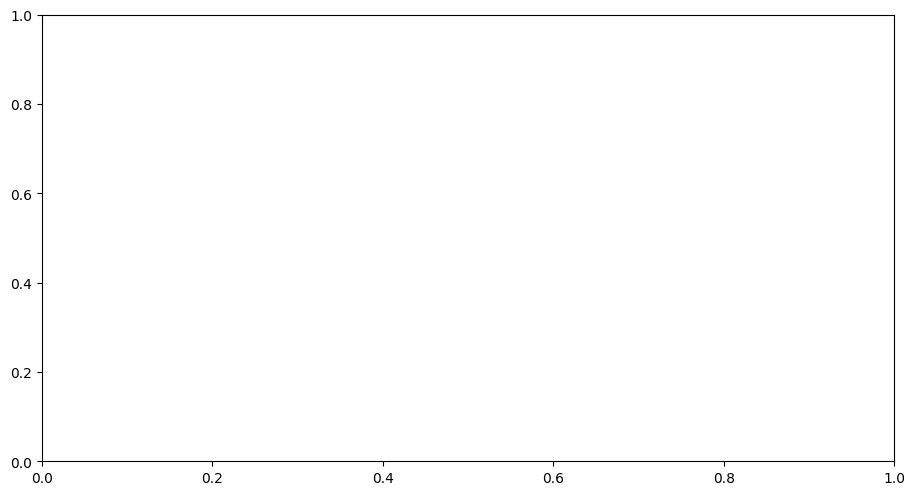

In [44]:
setup_color = {
    "concrete": "#4C72B0",
    "abstract": "#DD8452",
    "abbrev": "#55A868",
}

x = np.arange(len(model_order))
bar_width = 0.24

saved_paths = []

for formula in formula_order:
    sub = df[df["formula"] == formula]

    fig, ax = plt.subplots(figsize=(11, 5.8))

    for offset_idx, setup in enumerate(setup_order):
        setup_sub = (
            sub[sub["setup"] == setup]
            .set_index("model")
            .reindex(model_order)
        )

        y = setup_sub["success_rate"].values
        offset = (offset_idx - 1) * bar_width

        bars = ax.bar(
            x + offset,
            y,
            width=bar_width,
            label=setup_label.get(setup, setup),
            color=setup_color.get(setup, None),
        )

        # Add value labels on top of visible bars
        for bar, val in zip(bars, y):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    ax.set_title(
        f"{formula_label.get(formula, formula)}: Success Rate by Model and Setup",
        fontsize=14,
        pad=14,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [model_label.get(m, m) for m in model_order],
        rotation=25,
        ha="right",
        fontsize=10,
    )

    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Success Rate", fontsize=11)
    ax.set_xlabel("Model", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False, loc="upper right")

    # Add note for formulas without abbreviated setup
    observed_setups = set(sub["setup"].astype(str))
    if "abbrev" not in observed_setups:
        ax.text(
            0.01,
            0.96,
            "No abbreviated setup for this formula",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            color="gray",
        )

    plt.tight_layout()

    out_path = MODEL_COMP_DIR / f"model_comparison_{formula}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    saved_paths.append(str(out_path))
    print(f"Saved: {out_path}")

In [45]:
display(df.head())
print(df.columns)

,folder_name,summary_path,formula,setup,model,success_rate,n_runs
0,resistors_concrete_qwen25_3b__7i3lwokj,wandb_run_files\resistors_concrete_qwen25_3b__...,resistors,concrete,qwen25_3b,0.833333,30.0
1,resistors_abstract_qwen25_3b__62p28dog,wandb_run_files\resistors_abstract_qwen25_3b__...,resistors,abstract,qwen25_3b,0.300000,30.0
2,ohm_concrete_qwen25_3b__ktebi5qx,wandb_run_files\ohm_concrete_qwen25_3b__ktebi5...,ohm,concrete,qwen25_3b,0.433333,30.0
3,ohm_abstract_qwen25_3b__499ontvs,wandb_run_files\ohm_abstract_qwen25_3b__499ont...,ohm,abstract,qwen25_3b,0.033333,30.0
4,ohm_abbrev_qwen25_3b__skzxlqaa,wandb_run_files\ohm_abbrev_qwen25_3b__skzxlqaa...,ohm,abbrev,qwen25_3b,0.100000,30.0


Index(['folder_name', 'summary_path', 'formula', 'setup', 'model',
       'success_rate', 'n_runs'],
      dtype='str')


In [46]:
MODEL_COMP_DIR = FIG_DIR_04 / "model_focused_comparisons"
MODEL_COMP_DIR.mkdir(parents=True, exist_ok=True)

print(MODEL_COMP_DIR.resolve())

NameError: name 'FIG_DIR_04' is not defined